#### Import/install

##### Setup

In [1]:
# ### CELL 11: Install Required Libraries (stable Windows/Anaconda setup)
# # %load_ext autoreload
# # %autoreload 2

# # Use user site-packages to avoid permission/lock issues in base Anaconda folders.
# %pip install --upgrade pip
# %pip install --user --index-url https://download.pytorch.org/whl/cpu torch torchvision torchaudio

# %pip install xlsxwriter
# %pip install optuna
# %pip install stable-baselines3 gymnasium sb3-contrib
# %pip install seaborn

# %pip install plotly
# %pip install pulp
# %pip install nbformat
# %pip install scikit-learn

# print("After package updates, restart the kernel once before imports.")

In [2]:
### CELL 12: Import Libraries
import pandas as pd
import numpy as np
#import IPython.display as display
from matplotlib import pyplot as plt
import matplotlib.dates as mdates
from datetime import date, datetime
#from mpl_toolkits.mplot3d import Axes3D
#from matplotlib import cm
#import io
#import base64
# for generating random values
import random
# for copying python objects
import copy
import sys

import json
from pathlib import Path

from sklearn.linear_model import LinearRegression

from enum import Enum  #Za definicijo stvari ki jih definiram z celimi števili npr, katero akcijo bomo naredili
from datetime import datetime
import seaborn as sns
import os
import importlib

# try:
#     from google.colab import files #TYPE: ignore
#     IN_COLAB = True
# except ImportError:
#     IN_COLAB = False
IN_COLAB = os.path.exists('/content')    
IN_MAC = sys.platform == "darwin"
IN_WINDOWS = sys.platform == "win32"

import xlsxwriter

from pathlib import Path
import re

import torch as T
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
# import gym
from collections import deque

import pulp

# 1. Check for NVIDIA CUDA (Linux/Windows)
if T.cuda.is_available():
    device = T.device("cuda")
    print(f"Using NVIDIA CUDA GPU: {T.cuda.get_device_name(0)}")

# 2. Check for Apple Silicon MPS (Mac M1/M2/M3/M4)
elif T.backends.mps.is_available():
    device = T.device("mps")
    print("Using Apple Silicon MPS Acceleration")

# 3. Fallback to CPU
else:
    device = T.device("cpu")
    print("Using CPU")

# Example: Sending a tensor to the selected device
x = T.rand(3, 3, device=device)
print("\nTensor created on device:", x.device)

from matplotlib.lines import Line2D
import optuna
from optuna.visualization import plot_optimization_history, plot_param_importances

# Optional legacy helpers (kept backward-compatible if file exists)
try:
    from Normalization_Functions import normalize_dataset, ResultConverter, normalize_single_value
except ImportError:
    normalize_dataset = None
    ResultConverter = None
    normalize_single_value = None

import Environment as environment_module
importlib.reload(environment_module)
HouseholdEnvironment = environment_module.HouseholdEnvironment

from Basic_Functions import (
    Action,
    calculate_interval_price,
    run_milp_benchmark,
    milp_total_cost,
    cumulative_interval_price_series,
)

from Ploting_Functions import plotMultiY

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
# from sklearn.ensemble import RandomForestClassifier
# from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from types import SimpleNamespace

Using Apple Silicon MPS Acceleration

Tensor created on device: mps:0


/Users/summerscholl/Library/Python/3.14/lib/python/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# Test 1: Check if the file exists
import os
import importlib
import sys
file_path = "Ploting_Functions.py"
print(f"File exists: {os.path.exists(file_path)}")
print(f"Current directory: {os.getcwd()}")

# Test 1b: Inspect file contents for function name
try:
    with open(file_path, "r", encoding="utf-8", errors="replace") as f:
        content = f.read()
    print(f"File length: {len(content)}")
    print(f"First 200 chars: {content[:200]!r}")
    print(f"'plotMultiY' in file: {'plotMultiY' in content}")
    for line in content.splitlines():
        if "def" in line:
            print(f"DEF LINE: {line!r}")
except Exception as e:
    print(f"Error reading file: {type(e).__name__}: {e}")

# Test 2: Import module and inspect (force reload)
try:
    if "Ploting_Functions" in sys.modules:
        del sys.modules["Ploting_Functions"]
    import Ploting_Functions as pf
    pf = importlib.reload(pf)
    print("Module imported successfully")
    print(f"Module file: {pf.__file__}")
    print(f"Has plotMultiY: {hasattr(pf, 'plotMultiY')}")
    print(f"Names containing 'plot': {[n for n in dir(pf) if 'plot' in n.lower()]}")
except Exception as e:
    print(f"Error importing module: {type(e).__name__}: {e}")
    import traceback
    traceback.print_exc()

# Test 3: Direct function import
try:
    from Ploting_Functions import plotMultiY
    print("✓ plotMultiY imported successfully")
except Exception as e:
    print(f"✗ Cannot import plotMultiY: {type(e).__name__}: {e}")
    import traceback
    traceback.print_exc()

# Test 4: Direct function access from module
try:
    _ = pf.plotMultiY
    print("✓ plotMultiY resolved from module")
except Exception as e:
    print(f"✗ Cannot access plotMultiY from module: {type(e).__name__}: {e}")
    import traceback
    traceback.print_exc()

File exists: True
Current directory: /Users/summerscholl/Documents/Andraz/Household-RL
File length: 11380
First 200 chars: '### CELL 13: Function for Plotting Graphs\nimport matplotlib.pyplot as plt\nimport matplotlib.dates as mdates\nfrom datetime import date, datetime\n\n"Funkcija za risanje grafov"\ndef plotMultiY(X, Y=None, '
'plotMultiY' in file: True
DEF LINE: 'def plotMultiY(X, Y=None, X_label="X_os", Y_Label=None,'
DEF LINE: 'def plot_btr_comparison(comparison_df, metric="price_mean", title="BTR Algorithm Comparison", save=False):'
DEF LINE: 'def plot_training_progress(timestamps, rewards, prices=None, algorithm_name="BTR", title="Training Progress", save=False):'
DEF LINE: 'def plot_price_distribution(results_df, algorithm_filter=None, title="Energy Cost Distribution", save=False):'
DEF LINE: 'def plot_reward_vs_price(comparison_df, title="Reward vs Energy Cost Trade-off", save=False):'
DEF LINE: 'def plot_algorithm_ranking(comparison_df, metric="price_mean", ascending=True, t

##### Inport

In [4]:
#### CELL 15: Load Dataset - Adjusted to Use Relative Path for Local File

if IN_COLAB:
    from google.colab import files
    print("Running in Colab")
    VhodniPodatki = pd.read_csv("/content/Household-RL/VhodniPodatki.csv")
elif IN_WINDOWS or IN_MAC:    #Windows or MAC
    VhodniPodatki = pd.read_csv("Datasorted by user/Ausgrid 29.csv")  # Use relative path for local file ("Datasorted by user/Ausgrid 1.csv")VhodniPodatki
VhodniPodatki.index = pd.to_datetime(VhodniPodatki['Timestamp_UTC'], format='ISO8601')
VhodniPodatki = VhodniPodatki.drop(columns=['Timestamp_UTC'])
CenaMer = pd.DataFrame(VhodniPodatki["SMP"])
SoncnaMer = pd.DataFrame(VhodniPodatki["Energy_Generation"])
PorabaMer = pd.DataFrame(VhodniPodatki["Energy_Consumption"])

In [5]:
### CELL 16: Split Dataset into Training and Testing Sets
# test_size = 0.5  # test size
test_size = 1/3  # test size
train_data, test_data = train_test_split(
    VhodniPodatki,
    test_size=test_size,
    shuffle=False
)

#### Osnovne funkcije

In [6]:
### CELL 21: Define General Functions
'Definicija splosnih funkcij'

# Battery transfer limits are specified per 15-minute step.
BASE_STEP_MINUTES = 15.0
BAT_MAX_POLNJENJE_BASE = 1.5
BAT_MAX_PRAZNJENJE_BASE = 1.5

# Infer dataset resolution and adapt all per-step parameters.
step_minutes = (
    VhodniPodatki.index.to_series().sort_values().diff().dropna().dt.total_seconds().median() / 60.0
)
if not np.isfinite(step_minutes) or step_minutes <= 0:
    step_minutes = BASE_STEP_MINUTES

KorakovNaDan = int(round((24 * 60) / step_minutes))
step_scale = float(step_minutes / BASE_STEP_MINUTES)

BatMaxPolnjenje = BAT_MAX_POLNJENJE_BASE * step_scale
BatMaxPraznjenje = BAT_MAX_PRAZNJENJE_BASE * step_scale
BatKapaciteta = 20
BatUcinkovitost = 0.95

fc1_dims = 64 * 4
fc2_dims = 32 * 4
fc3_dims = 16 * 4

lr = 0.001
gamma = 0.99
epsilon_start = 1.0
epsilon_end = 0.01
epsilon_decay = 4e-5
batch_size = KorakovNaDan
replace_target = KorakovNaDan * 7

weight_decay = 1e-4

faktorN1 = 0
faktorN2 = 0
faktorN3 = 1


GENERATE_DQN_INVOICE      = True
GENERATE_BASELINE_INVOICE = True
GENERATE_MILP_INVOICE     = True

print(
    f"Detected step: {step_minutes:.1f} min | KorakovNaDan={KorakovNaDan} | "
    f"BatMaxPolnjenje={BatMaxPolnjenje:.3f} | BatMaxPraznjenje={BatMaxPraznjenje:.3f}"
)

Detected step: 30.0 min | KorakovNaDan=48 | BatMaxPolnjenje=3.000 | BatMaxPraznjenje=3.000


In [7]:
### CELL 23: Normalize the dataset

# --- 1. CONFIGURATION ---
# Options: MinMaxScaler, StandardScaler, RobustScaler
ScalerClass = RobustScaler

# Configuration for columns
shared_cols = ['Energy_Generation', 'Energy_Consumption']
independent_cols = [c for c in train_data.columns if c not in shared_cols + ['SMP']]

# --- 2. INITIALIZE SCALERS ---
# We use **kwargs so we can pass arguments only if the scaler supports them
scaler_args = {}

if ScalerClass == MinMaxScaler:
    scaler_args['feature_range'] = (0, 1)

# Create two separate instances of the CHOSEN class
scaler_shared = ScalerClass(**scaler_args)
scaler_indep = ScalerClass(**scaler_args)

# --- 3. FIT THE SCALERS ---

# A. Shared Scaler (Stacked fit)
# Flatten combined data so the scaler learns Global Min/Max or Global Mean/Std
combined_energy_data = train_data[shared_cols].values.flatten().reshape(-1, 1)
scaler_shared.fit(combined_energy_data)

# B. Independent Scaler (Normal fit)
if independent_cols:
    scaler_indep.fit(train_data[independent_cols])

# --- 4. SMP-SPECIFIC PRICE NORMALIZATION ---
def normalize_electricity_prices(data, fit=False, params=None):
    # Ensure data is 2D for the Scaler (N samples, 1 feature)
    if data.ndim == 1:
        data = data.reshape(-1, 1)

    # --- Step 1: Outlier Detection & Flagging ---
    # Fit thresholds only on train split, then reuse on test to avoid leakage.
    if fit:
        upper_threshold = np.percentile(data, 99.5)
        lower_threshold = np.percentile(data, 0.1)
    else:
        if params is None:
            raise ValueError("params must be provided when fit=False")
        upper_threshold = params['upper_threshold']
        lower_threshold = params['lower_threshold']

    # Create binary flag: 1 if it's an extreme event, 0 otherwise
    # We convert to float so it plays nice with neural network inputs
    outlier_flag = ((data > upper_threshold) | (data < lower_threshold)).astype(float)

    # --- Step 2: Log Transformation ---
    # np.maximum(data, 0) handles rare negative prices before log1p
    log_data = np.log1p(np.maximum(data, 0))

    # --- Step 3: Clipping (Winsorization) ---
    # We clip the log-data to the same percentiles used for the flag
    # This prevents the DQN gradients from exploding during those ~2 days a year
    log_lower = np.log1p(max(0, lower_threshold))
    log_upper = np.log1p(max(0, upper_threshold))
    clipped_data = np.clip(log_data, log_lower, log_upper)

    # --- Step 4: Robust Scaling ---
    # Fit scaler on train, reuse for test.
    if fit:
        scaler = RobustScaler()
        normalized_prices = scaler.fit_transform(clipped_data)
        fitted_params = {
            'upper_threshold': float(upper_threshold),
            'lower_threshold': float(lower_threshold),
            'log_lower': float(log_lower),
            'log_upper': float(log_upper),
            'scaler': scaler,
        }
    else:
        scaler = params['scaler']
        normalized_prices = scaler.transform(clipped_data)
        fitted_params = params

    # Return normalized price, outlier flag and fitted params for reuse.
    return normalized_prices, outlier_flag, fitted_params

# --- 5. APPLY TRANSFORMATION FUNCTION ---
def apply_scaling(df, scaler_shared, scaler_indep, shared_cols, indep_cols):
    df_scaled = df.copy()

    # Transform Shared Columns
    # We must transform one by one because scaler_shared expects a single column input shape
    for col in shared_cols:
        col_values = df[col].values.reshape(-1, 1)
        # flatten() ensures we put a 1D array back into the dataframe
        df_scaled[col] = scaler_shared.transform(col_values).flatten()

    # Transform Independent Columns
    if indep_cols:
        df_scaled[indep_cols] = scaler_indep.transform(df[indep_cols])

    return df_scaled

# --- 6. EXECUTE ---
train_data_norm = apply_scaling(train_data, scaler_shared, scaler_indep, shared_cols, independent_cols)
test_data_norm = apply_scaling(test_data, scaler_shared, scaler_indep, shared_cols, independent_cols)

train_smp_norm, train_smp_outlier, price_norm_params = normalize_electricity_prices(train_data['SMP'].values, fit=True)
test_smp_norm, test_smp_outlier, _ = normalize_electricity_prices(test_data['SMP'].values, fit=False, params=price_norm_params)

train_data_norm['SMP'] = train_smp_norm.flatten()
test_data_norm['SMP'] = test_smp_norm.flatten()
train_data_norm['SMP_OutlierFlag'] = train_smp_outlier.flatten()
test_data_norm['SMP_OutlierFlag'] = test_smp_outlier.flatten()

print(f"Using Scaler: {ScalerClass.__name__}")
print(train_data_norm.head())



Using Scaler: RobustScaler
                           Energy_Consumption  Energy_Generation       SMP  \
Timestamp_UTC                                                                
2010-07-01 00:30:00+00:00            0.088983           -0.34322  0.569624   
2010-07-01 01:00:00+00:00           -0.105932           -0.34322  0.552432   
2010-07-01 01:30:00+00:00           -0.021186           -0.34322  1.129532   
2010-07-01 02:00:00+00:00            0.122881           -0.34322  1.004249   
2010-07-01 02:30:00+00:00           -0.029661           -0.34322  0.487091   

                           SMP_OutlierFlag  
Timestamp_UTC                               
2010-07-01 00:30:00+00:00              0.0  
2010-07-01 01:00:00+00:00              0.0  
2010-07-01 01:30:00+00:00              0.0  
2010-07-01 02:00:00+00:00              0.0  
2010-07-01 02:30:00+00:00              0.0  


#### Environment/okolje

In [8]:
### CELL 31: Use Gymnasium Environment (HouseholdEnvironment)
def build_dqn_env(
    dataset,
    dataset_norm,
    episode_length,
    reset_mode="deterministic",
    observation_mode="sliding_window",
    generate_monthly_invoice=False,
    generate_period_invoice=False,
    invoice_run_label=None,
):
    return HouseholdEnvironment(
        dataset=dataset,
        dataset_norm=dataset_norm,
        observation_mode=observation_mode,
        reset_mode=reset_mode,
        episode_length=episode_length,
        korakov_na_dan=KorakovNaDan,
        bat_kapaciteta=BatKapaciteta,
        bat_ucinkovitost=BatUcinkovitost,
        bat_max_polnjenje=BatMaxPolnjenje,
        bat_max_praznjenje=BatMaxPraznjenje,
        faktor_n1=faktorN1,
        faktor_n2=faktorN2,
        faktor_n3=faktorN3,
        generate_monthly_invoice=generate_monthly_invoice,
        generate_period_invoice=generate_period_invoice,
        invoice_run_label=invoice_run_label,
    )

print("Notebook DQN now uses HouseholdEnvironment directly")

Notebook DQN now uses HouseholdEnvironment directly


In [9]:
### CELL 32: Prepare deterministic DQN evaluation environment
# %%time
eval_env = build_dqn_env(
    dataset=test_data,
    dataset_norm=test_data_norm,
    episode_length=len(test_data) - 1,
    reset_mode="deterministic",
    observation_mode="sliding_window",
)

print("Prepared deterministic DQN evaluation environment.")

Prepared deterministic DQN evaluation environment.


## DQN

### Setup DQN

In [10]:
class DeepQNetwork(nn.Module):
    def __init__(self, lr, layer_dims, weight_decay=1e-4):
        super(DeepQNetwork, self).__init__()
        self.layer_dims = list(layer_dims)

        self.layers = nn.ModuleList([
            nn.Linear(in_dim, out_dim)
            for in_dim, out_dim in zip(self.layer_dims[:-1], self.layer_dims[1:])
        ])

        self.optimizer = optim.AdamW(self.parameters(), lr=lr, weight_decay=weight_decay)
        #self.loss = nn.MSELoss()
        # SmoothL1 (Huber) is typically more stable than MSE for noisy TD targets.
        self.loss = nn.SmoothL1Loss(beta=1.0)

        self.device = T.device('cuda:0' if T.cuda.is_available() else 'cpu')

        nn.init.constant_(self.layers[-1].bias, 0.1)
        self.to(self.device)

    def forward(self, state):
        x = state
        for layer in self.layers[:-1]:
            x = F.relu(layer(x))
        return self.layers[-1](x)


class AgentDQN:
    def __init__(
        self,
        gamma,
        epsilon,
        lr,
        state_shape,
        network_dims,
        batch_size,
        replace_target=replace_target,
        max_mem_size=1_000_000,
        eps_end=0.05,
        eps_dec=4e-5,
        weight_decay=weight_decay,
        tau=0.005,
        start_learning_after=None,
    ):
        self.gamma = gamma
        self.epsilon = epsilon
        self.eps_min = eps_end
        self.eps_dec = eps_dec
        self.lr = lr
        self.batch_size = batch_size
        self.mem_size = max_mem_size
        self.mem_cntr = 0
        self.iter_cntr = 0
        self.replace_target = replace_target
        self.tau = float(tau) if tau is not None else 0.0

        self.state_shape = list(state_shape)
        self.network_dims = list(network_dims)
        self.n_actions = self.network_dims[-1]
        self.action_space = list(range(self.n_actions))

        self.Q_eval = DeepQNetwork(lr=lr, layer_dims=self.network_dims, weight_decay=weight_decay)
        self.Q_target = DeepQNetwork(lr=lr, layer_dims=self.network_dims, weight_decay=weight_decay)
        self.Q_target.load_state_dict(self.Q_eval.state_dict())
        self.Q_target.eval()

        if start_learning_after is None:
            self.start_learning_after = int(4 * self.batch_size)
        else:
            self.start_learning_after = int(max(start_learning_after, self.batch_size))

        self.state_memory = np.zeros((self.mem_size, *self.state_shape), dtype=np.float32)
        self.new_state_memory = np.zeros((self.mem_size, *self.state_shape), dtype=np.float32)
        self.action_memory = np.zeros(self.mem_size, dtype=np.int32)
        self.reward_memory = np.zeros(self.mem_size, dtype=np.float32)
        self.terminal_memory = np.zeros(self.mem_size, dtype=np.bool_)

    def store_transition(self, state, action, reward, state_, terminal):
        index = self.mem_cntr % self.mem_size
        self.state_memory[index] = state
        self.new_state_memory[index] = state_
        self.reward_memory[index] = reward
        self.action_memory[index] = action
        self.terminal_memory[index] = terminal

        self.mem_cntr += 1

    def choose_action(self, observation):
        if np.random.random() > self.epsilon:   #Epsilon greedy
            state = T.tensor(np.array([observation]), dtype=T.float32).to(self.Q_eval.device)   #Pripravi vektor state za naslenji korak
            actions = self.Q_eval.forward(state)    #Požene stanja čez nevronsko mrežo in si zapomni vrednosti za vse akcije
            action = T.argmax(actions).item()       #Izbere akcijo, ki naj bi ila najboljša
            # print(f"Chose action {action} with Q-values {actions.cpu().detach().numpy()} and epsilon {self.epsilon:.4f}")
        else:
            action = np.random.choice(self.action_space)

        return action

    def _soft_update_target(self):
        with T.no_grad():
            for target_param, eval_param in zip(self.Q_target.parameters(), self.Q_eval.parameters()):
                target_param.data.mul_(1.0 - self.tau).add_(self.tau * eval_param.data)

    def learn(self):
        if self.mem_cntr < self.start_learning_after:
            return

        max_mem = min(self.mem_cntr, self.mem_size)  #Velikost zasedenega spomina ko state_memory prvič napolnimo ostane mem_size
        if max_mem < self.batch_size:
            return

        batch = np.random.choice(max_mem, self.batch_size, replace=False)   #Vrne batch_size lokacij iz spomina ki se ne ponavljajo replace=False
        batch_index = np.arange(self.batch_size, dtype=np.int32)            #Ustvari vektor celih števil od 0 pa do batch_size

        state_batch = T.tensor(self.state_memory[batch], dtype=T.float32, device=self.Q_eval.device)
        new_state_batch = T.tensor(self.new_state_memory[batch], dtype=T.float32, device=self.Q_eval.device)
        action_batch_t = T.tensor(self.action_memory[batch], dtype=T.long, device=self.Q_eval.device)
        reward_batch = T.tensor(self.reward_memory[batch], dtype=T.float32, device=self.Q_eval.device)
        terminal_batch_t = T.tensor(self.terminal_memory[batch], dtype=T.float32, device=self.Q_eval.device)

        q_eval_all = self.Q_eval(state_batch)
        q_eval = q_eval_all[batch_index, action_batch_t]

        with T.no_grad():
            next_actions = self.Q_eval(new_state_batch).argmax(dim=1, keepdim=True)

            # B) Vrednotenje akcije z Q_TARGET mrežo
            # Vprašamo ciljno mrežo: "Kakšna je vrednost te akcije, ki jo je izbrala glavna mreža?"
            q_next = self.Q_target(new_state_batch).gather(1, next_actions).squeeze(1)

            # C) Končna ciljna vrednost (Bellmanova enačba)
            # Če je stanje terminalno, je q_next enak 0
            q_target = reward_batch + self.gamma * q_next * (1 - terminal_batch_t)


        loss = self.Q_eval.loss(q_eval, q_target).to(self.Q_eval.device)
        self.Q_eval.optimizer.zero_grad()   #Pozabimo staro vrednost sicer jo pytorch avtomatsko združi z novo in pride do napake
        loss.backward()     #Sproži backpropagation napake da se popravijo tudi predvidena stanja, ki so pripeljala do tegas
        T.nn.utils.clip_grad_norm_(self.Q_eval.parameters(), max_norm=1.0)  #Gradient clipping for stability
        self.Q_eval.optimizer.step()    #Posodobi parametre modela ki smo jih dobili z prejšnjim korakom

        self.iter_cntr += 1
        self.epsilon = self.epsilon - self.eps_dec if self.epsilon > self.eps_min else self.eps_min

        if self.tau > 0.0:
            self._soft_update_target()
        elif self.iter_cntr % self.replace_target == 0:
            self.Q_target.load_state_dict(self.Q_eval.state_dict())

In [11]:
import datetime as dt
import os
import time
import random


def _save_dqn_checkpoint(agent, checkpoint_file, network_dims, episode_idx=None, extra=None):
    payload = {
        "state_dict": agent.Q_eval.state_dict(),
        "network_dims": list(network_dims),
        "episode": int(episode_idx) if episode_idx is not None else None,
        "saved_at": dt.datetime.now().isoformat(),
    }
    if extra:
        payload.update(extra)

    tmp_file = checkpoint_file + ".tmp"
    T.save(payload, tmp_file)
    os.replace(tmp_file, checkpoint_file)


def set_global_seed(seed):
    if seed is None:
        return

    random.seed(seed)
    np.random.seed(seed)
    T.manual_seed(seed)

    if T.cuda.is_available():
        T.cuda.manual_seed_all(seed)
        T.backends.cudnn.deterministic = True
        T.backends.cudnn.benchmark = False


def _update_optimizer_lr(agent, new_lr):
    if new_lr is None:
        return

    if hasattr(agent, "Q_eval") and hasattr(agent.Q_eval, "optimizer"):
        for group in agent.Q_eval.optimizer.param_groups:
            group["lr"] = float(new_lr)

    if hasattr(agent, "Q_target") and hasattr(agent.Q_target, "optimizer"):
        for group in agent.Q_target.optimizer.param_groups:
            group["lr"] = float(new_lr)

    agent.lr = float(new_lr)


def Learning_DQN(epsilon=None, reset=False, ponovitev=52, epsilon_decay=None,
                 epsilon_end=None, analiziran_kos=None, ucenje=True, random=False,
                 lr=None, agent=None, env=None,
                 eval_epsilon=0.0, seed=None,
                 deterministic_starts=False, start_learning_after=None,
                 checkpoint_every=5, diag_tag="dqn", invoice_flag=None):

    # Resolve defaults at call time so Optuna-updated globals are used.
    if epsilon is None:
        epsilon = epsilon_start
    if epsilon_decay is None:
        epsilon_decay = globals().get("epsilon_decay")
    if epsilon_end is None:
        epsilon_end = globals().get("epsilon_end")
    if analiziran_kos is None:
        analiziran_kos = batch_size
    if lr is None:
        lr = globals().get("lr")
    if invoice_flag is None:
        invoice_flag = globals().get("GENERATE_DQN_INVOICE", False)

    set_global_seed(seed)

    episodes = ponovitev
    shrani = True
    nalozi = (agent is None)

    data = train_data if ucenje else test_data
    data_norm = train_data_norm if ucenje else test_data_norm

    if not ucenje:
        shrani = False
        nalozi = (agent is None)
        epsilon = 0
        epsilon_end = 0
        episodes = 1
        steps_per_episode = len(data) - 1
    else:
        steps_per_episode = KorakovNaDan * 7

    if random:
        epsilon = 1
        epsilon_end = 1

    # Build gym environment if not provided.
    if env is None or reset:
        env_reset_mode = "deterministic" if (not ucenje or deterministic_starts) else "random"
        env = build_dqn_env(
            dataset=data,
            dataset_norm=data_norm,
            episode_length=steps_per_episode,
            reset_mode=env_reset_mode,
            observation_mode="sliding_window",
            # Invoicing only makes sense for a deterministic chronological
            # pass -- on for the eval env (not ucenje), off for training.
            generate_monthly_invoice=(not ucenje)*invoice_flag,
            generate_period_invoice=(not ucenje)*invoice_flag,
            invoice_run_label=("dqn_eval" if (not ucenje) and invoice_flag else None),
        )

    old_agent_epsilon = None

    state_shape = [int(env.observation_space.shape[0])]
    network_dims = [state_shape[0], fc1_dims, fc2_dims, fc3_dims, len(Action)]

    if agent is None or reset:
        agent = AgentDQN(
            gamma=gamma,
            epsilon=epsilon,
            lr=lr,
            state_shape=state_shape,
            network_dims=network_dims,
            batch_size=analiziran_kos,
            eps_end=epsilon_end,
            eps_dec=epsilon_decay,
            replace_target=replace_target,
            weight_decay=weight_decay,
            start_learning_after=start_learning_after,
        )
    else:
        # Keep continuation runs consistent when reusing an already-trained agent.
        agent.epsilon = float(epsilon)
        agent.eps_min = float(epsilon_end)
        agent.eps_dec = float(epsilon_decay)
        agent.batch_size = int(analiziran_kos)
        if start_learning_after is not None:
            agent.start_learning_after = int(max(start_learning_after, agent.batch_size))
        _update_optimizer_lr(agent, lr)

    nagradaDQN, placiloDQN = [0], [0]
    NagradaKapaciteta, NagradaSprememba, NagradaPlacilo = [0], [0], [0]
    baterijaDQN = [BatKapaciteta / 2]

    name = "dqn_model"
    chkpt_dir = "DQN"
    checkpoint_dir = chkpt_dir

    if not os.path.exists(checkpoint_dir):
        os.makedirs(checkpoint_dir)
    checkpoint_file = os.path.join(checkpoint_dir, name)

    # Reset mode must start from clean weights even if a previous checkpoint exists.
    if reset:
        nalozi = False
        if os.path.exists(checkpoint_file):
            try:
                os.remove(checkpoint_file)
                print("Reset requested: removed old DQN checkpoint.")
            except OSError as exc:
                msg = f"Reset requested: could not remove old checkpoint ({exc}). Continuing without loading."
                print(msg)

    ckpt_dims = None
    state_dict = None
    if nalozi and os.path.exists(checkpoint_file):
        ckpt = T.load(checkpoint_file, weights_only=False)

        # Backward compatibility: old checkpoints may be plain state_dict.
        if isinstance(ckpt, dict) and "state_dict" in ckpt:
            state_dict = ckpt["state_dict"]
            ckpt_dims = ckpt.get("network_dims", None)
        else:
            state_dict = ckpt
            ckpt_dims = None

    if nalozi and state_dict is not None:
        if (ckpt_dims is None) or (list(ckpt_dims) == list(network_dims)):
            agent.Q_eval.load_state_dict(state_dict)
            agent.Q_target.load_state_dict(agent.Q_eval.state_dict())
            agent.Q_target.eval()
        else:
            print("Skipping checkpoint load: architecture mismatch.")
    elif nalozi:
        print("Checkpoint not found; starting from randomly initialized weights.")

    if not ucenje:
        # eval_epsilon=0.0  -> deterministic (greedy), > 0 -> stochastic robustness test
        if not random:
            old_agent_epsilon = agent.epsilon
            agent.epsilon = float(eval_epsilon)
            if eval_epsilon > 0.0:
                print(f"Stochastic eval: epsilon = {eval_epsilon:.4f}")
            else:
                print("Deterministic eval: epsilon = 0.0 (greedy)")
        if random:
            agent.epsilon = 1.0
            print("Random eval: epsilon = 1.0")

    print(f"Episode: {episodes}")
    print(f"Steps per episode: {steps_per_episode}")

    for i in range(episodes):
        done = False
        episode_reward = 0.0

        if not ucenje:
            reset_options = {"reset_mode": "deterministic"}
        else:
            if deterministic_starts:
                reset_options = {"reset_mode": "sequential", "sequential_n": max(episodes, 1)}
            else:
                reset_options = {"reset_mode": "random"}

        try:
            obs, info = env.reset(options=reset_options)
            print(f"Epsilon {agent.epsilon:.4f}")

            step_count = 0
            while step_count < steps_per_episode and not done:
                action = agent.choose_action(obs)
                next_obs, reward, terminated, truncated, step_info = env.step(action)
                done_next = bool(terminated or truncated)

                if ucenje:
                    agent.store_transition(obs, action, reward, next_obs, done_next)
                    agent.learn()

                obs = next_obs
                done = done_next
                step_count += 1
                episode_reward += reward

                nagradaDQN.append(nagradaDQN[-1] + reward)
                placiloDQN.append(float(step_info.get("cumulative_payment", placiloDQN[-1])))
                baterijaDQN.append(float(step_info.get("battery", baterijaDQN[-1])))

                reward_components = step_info.get("reward_components", {})
                NagradaKapaciteta.append(float(reward_components.get("r_kapaciteta", 0.0)))
                NagradaSprememba.append(float(reward_components.get("r_sprememba", 0.0)))
                NagradaPlacilo.append(float(reward_components.get("r_placilo", 0.0)))

            if shrani and (((i + 1) % max(int(checkpoint_every), 1)) == 0 or (i + 1) == episodes):
                _save_dqn_checkpoint(
                    agent,
                    checkpoint_file,
                    network_dims,
                    episode_idx=i + 1,
                    extra={
                        "epsilon": float(agent.epsilon),
                        "learning": bool(ucenje),
                    },
                )

        except Exception:
            if shrani:
                _save_dqn_checkpoint(
                    agent,
                    checkpoint_file,
                    network_dims,
                    episode_idx=i,
                    extra={
                        "epsilon": float(agent.epsilon),
                        "learning": bool(ucenje),
                    },
                )
            raise

    if shrani:
        _save_dqn_checkpoint(
            agent,
            checkpoint_file,
            network_dims,
            episode_idx=episodes,
            extra={
                "epsilon": float(agent.epsilon),
                "learning": bool(ucenje),
            },
        )

    if old_agent_epsilon is not None:
        agent.epsilon = old_agent_epsilon

    if not ucenje:
        print(f"Final price: {placiloDQN[-1]:.2f} EUR")
        return nagradaDQN, placiloDQN, baterijaDQN, NagradaKapaciteta, NagradaSprememba, NagradaPlacilo
    else:
        return agent, env

In [12]:
def build_plot_timeline(dataset, cumulative_series):
    return dataset.index[: max(len(cumulative_series) - 1, 0)]


def rollout_env_trace(env, policy_mode="fixed", reset_options=None):
    if policy_mode not in {"fixed", "random", "alternating"}:
        raise ValueError(f"Unsupported policy_mode: {policy_mode}")

    if reset_options is None:
        reset_options = {"reset_mode": "deterministic"}

    trace = SimpleNamespace(
        Date=[],
        Price=[0.0],
        Nagrada=[],
        NapolnjenostBaterije=[float(getattr(env, "battery", 0.0))],
        Cena=[],
        NagradaSkupno=[0.0],
        NagradaKapaciteta=[0.0],
        NagradaSprememba=[0.0],
        NagradaPlacilo=[0.0],
    )

    dataset_index = getattr(getattr(env, "dataset", None), "index", None)

    _, _ = env.reset(options=reset_options)
    done = False
    step_counter = 0

    while not done:
        if policy_mode == "random":
            action = int(np.random.choice(env.action_space.n))
        elif policy_mode == "alternating":
            action = int(step_counter % env.action_space.n)
        else:
            action = 0

        _, reward, terminated, truncated, step_info = env.step(action)
        reward_components = step_info.get("reward_components", {})

        trace.Price.append(float(step_info.get("cumulative_payment", trace.Price[-1])))
        if dataset_index is not None and len(dataset_index) > 0:
            trace.Date.append(dataset_index[min(step_counter, len(dataset_index) - 1)])
        else:
            trace.Date.append(step_counter)
        trace.Nagrada.append(float(reward))
        trace.NapolnjenostBaterije.append(
            float(step_info.get("battery", trace.NapolnjenostBaterije[-1]))
        )
        trace.Cena.append(
            float(reward_components.get("fixed_monthly_charge_eur", 0.0))
            + float(reward_components.get("placilo_zdaj", 0.0))
        )
        trace.NagradaSkupno.append(trace.NagradaSkupno[-1] + float(reward))
        trace.NagradaKapaciteta.append(
            trace.NagradaKapaciteta[-1] + float(reward_components.get("r_kapaciteta", 0.0))
        )
        trace.NagradaSprememba.append(
            trace.NagradaSprememba[-1] + float(reward_components.get("r_sprememba", 0.0))
        )
        trace.NagradaPlacilo.append(
            trace.NagradaPlacilo[-1] + float(reward_components.get("r_placilo", 0.0))
        )

        done = bool(terminated or truncated)
        step_counter += 1

    return trace

### Optimization

In [13]:
# Optimization horizons
OPT_TRAIN_EPISODES = 52           # default matches Learning_DQN ponovitev
OPT_HORIZON = KorakovNaDan * 7   # matches Learning_DQN steps_per_episode


def objective(trial, train_episodes=None):
    if train_episodes is None:
        train_episodes = OPT_TRAIN_EPISODES

    # --- Hyperparameters (unchanged) ---
    gamma_t = trial.suggest_float("gamma", 0.8, 0.99999, log=True)
    lr_t = trial.suggest_float("lr", 1e-5, 1e-2, log=True)
    epsilon_start_t = trial.suggest_float("epsilon_start", 0.8, 1.0)
    epsilon_end_t = trial.suggest_float("epsilon_end", 0.01, 0.15)
    total_steps = train_episodes * OPT_HORIZON
    exploration_fraction = trial.suggest_float("exploration_fraction", 0.3, 0.8)
    steps_to_decay = total_steps * exploration_fraction
    epsilon_decay_t = (epsilon_start_t - epsilon_end_t) / steps_to_decay
    batch_size_t = trial.suggest_categorical("batch_size", [32, 64, 96, 128])
    fc1_t = 512
    fc2_t = 256
    fc3_t = 128
    replace_target_t = trial.suggest_int("replace_target", KorakovNaDan * 3, KorakovNaDan * 30)
    weight_decay_t = trial.suggest_float("weight_decay", 0.0, 1e-3)

    # --- Split train_data into opt_train (first half) and opt_val (second half) ---
    n = len(train_data)
    split_idx = n // 2
    opt_train_data = train_data.iloc[:split_idx]
    opt_train_data_norm = train_data_norm.iloc[:split_idx]
    opt_val_data = train_data.iloc[split_idx:]
    opt_val_data_norm = train_data_norm.iloc[split_idx:]

    # --- Phase 1: Train on opt_train with random reset ---
    train_env = build_dqn_env(
        dataset=opt_train_data,
        dataset_norm=opt_train_data_norm,
        episode_length=OPT_HORIZON,
        reset_mode="random",
        observation_mode="sliding_window",
    )

    state_shape = [int(train_env.observation_space.shape[0])]
    network_dims = [state_shape[0], fc1_t, fc2_t, fc3_t, len(Action)]

    agent = AgentDQN(
        gamma=gamma_t,
        epsilon=epsilon_start_t,
        lr=lr_t,
        state_shape=state_shape,
        network_dims=network_dims,
        batch_size=batch_size_t,
        eps_end=epsilon_end_t,
        eps_dec=epsilon_decay_t,
        weight_decay=weight_decay_t,
        replace_target=replace_target_t,
    )

    episode_rewards = []
    for episode in range(train_episodes):
        obs, _ = train_env.reset(options={"reset_mode": "random"})
        episode_reward = 0.0

        for _ in range(OPT_HORIZON):
            a = agent.choose_action(obs)
            next_obs, r, terminated, truncated, _ = train_env.step(a)
            done = bool(terminated or truncated)

            agent.store_transition(obs, a, r, next_obs, done)
            agent.learn()

            obs = next_obs
            episode_reward += r

            if done:
                break

        episode_rewards.append(episode_reward)

        # Report rolling average for pruning
        rolling_score = sum(episode_rewards) / len(episode_rewards)
        trial.report(rolling_score, episode)

        if trial.should_prune():
            raise optuna.TrialPruned()

    # --- Phase 2: Validate on opt_val with sequential reset (greedy) ---
    val_env = build_dqn_env(
        dataset=opt_val_data,
        dataset_norm=opt_val_data_norm,
        episode_length=len(opt_val_data) - 1,
        reset_mode="sequential",
        observation_mode="sliding_window",
    )

    old_epsilon = agent.epsilon
    agent.epsilon = 0.0

    obs, _ = val_env.reset(options={"reset_mode": "sequential"})
    val_reward = 0.0

    for _ in range(len(opt_val_data) - 1):
        a = agent.choose_action(obs)
        obs, r, terminated, truncated, _ = val_env.step(a)
        val_reward += r
        if terminated or truncated:
            break

    agent.epsilon = old_epsilon

    return val_reward


study = optuna.create_study(
    direction="maximize",
    pruner=optuna.pruners.MedianPruner(n_startup_trials=20, n_warmup_steps=40),
)

print("Starting hyperparameter optimization...")
study.optimize(objective, n_trials=100, timeout=3600)

print("Optimization completed.")
print(f"Finished trials: {len(study.trials)}")
print(f"Best trial: {study.best_trial.number}")
print(f"Best value: {study.best_trial.value:.4f}")

best_params = study.best_trial.params

plot_optimization_history(study).show()
plot_param_importances(study).show()

[I 2026-07-30 12:14:54,048] A new study created in memory with name: no-name-7d7a5701-03e0-4d1d-ae9e-3c61c9fdd771


Starting hyperparameter optimization...


[W 2026-07-30 12:14:57,398] Trial 0 failed with parameters: {'gamma': 0.8081244082900934, 'lr': 5.755144939901356e-05, 'epsilon_start': 0.8441270812185561, 'epsilon_end': 0.04344325779879258, 'exploration_fraction': 0.48506871640346444, 'batch_size': 32, 'replace_target': 203, 'weight_decay': 0.0008404383909495488} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "/Users/summerscholl/Library/Python/3.14/lib/python/site-packages/optuna/study/_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
  File "/var/folders/39/ydgffyrd3m102wzr66n24xmr0000gr/T/ipykernel_59721/657889095.py", line 70, in objective
    agent.learn()
    ~~~~~~~~~~~^^
  File "/var/folders/39/ydgffyrd3m102wzr66n24xmr0000gr/T/ipykernel_59721/2257236656.py", line 112, in learn
    batch = np.random.choice(max_mem, self.batch_size, replace=False)   #Vrne batch_size lokacij iz spomina ki se ne ponavljajo replace=False
  File "numpy/random/mtrand.pyx", line 1

KeyboardInterrupt: 

In [ ]:
# apply best Optuna parameters
gamma = best_params['gamma']
lr = best_params['lr']
epsilon_start = best_params['epsilon_start']
epsilon_end = best_params['epsilon_end']
#epsilon_decay = best_params['epsilon_decay']
exploration_fraction = best_params['exploration_fraction']
total_steps = OPT_TRAIN_EPISODES * OPT_HORIZON
steps_to_decay = total_steps * exploration_fraction
epsilon_decay = (epsilon_start - epsilon_end) / steps_to_decay
batch_size = best_params['batch_size']
# fc1_dims = best_params['fc1_dims']
# fc2_dims = best_params['fc2_dims']
# fc3_dims = best_params['fc3_dims']
replace_target = best_params['replace_target']
weight_decay = best_params['weight_decay']

### Best param save/load

In [ ]:
if IN_COLAB:
    base_dir = Path("/content/drive/MyDrive/Colab Notebooks")
else:
    # Path(".") points to your current working directory on both Mac and Windows
    base_dir = Path(".") 

# Path combining handles the slashes automatically (e.g., '\' for Windows, '/' for Mac/Colab)
best_param_loc = base_dir / "Optimized hyperparameters" / "ausgrid123-mali-SUPER.json"

# Save best Optuna parameters to file
with open(best_param_loc, "w") as f:
    json.dump(best_params, f, indent=4)

print(f"Best parameters saved to {best_param_loc}")
print(best_params)


In [ ]:
if IN_COLAB:
    best_param_loc = "/content/Household-RL/Optimized hyperparameters/N011Fc66Bu95Bk20PoskusZVecjimNN-AUSGRID.json"
else:
    best_param_loc = "Optimized hyperparameters/N001Fc100Bu95Bk20velikNN-ausgrid123.json"
# Load best parameters from file
with open(best_param_loc, "r") as f:
    best_params = json.load(f)

gamma = best_params['gamma']
lr = best_params['lr']
epsilon_start = best_params['epsilon_start']
epsilon_end = best_params['epsilon_end']
#epsilon_decay = best_params['epsilon_decay']
exploration_fraction = best_params['exploration_fraction']
total_steps = OPT_EPISODES * OPT_HORIZON
steps_to_decay = total_steps * exploration_fraction
batch_size = best_params['batch_size']
fc1_dims = 512 #best_params['fc1_dims']
fc2_dims = 256 #best_params['fc2_dims']
fc3_dims = 128 #best_params['fc3_dims']
replace_target = best_params['replace_target']
weight_decay = best_params['weight_decay']

print("Loaded best parameters from BestParam1.json")
print(best_params)


### Uporaba DQN

In [14]:
faktorN1 = 0
faktorN2 = 0
faktorN3 = 1
BatUcinkovitost = 0.95
BatKapaciteta = 20

In [15]:
#%%time
train = Learning_DQN(reset = True) #, ponovitev=100
nagradaDQN , placiloDQN, baterijaDQN, NagradaKapaciteta, NagradaSprememba, NagradaPlacilo= Learning_DQN(ucenje=False)
print(f'Nagrada po optimizaciji {nagradaDQN[-1]}')
print(f'Cena po optimizaciji {placiloDQN[-1]}')
print(f'faktorN1: {faktorN1}')
print(f'faktorN2: {faktorN2}')
print(f'faktorN3: {faktorN3}')

Reset requested: removed old DQN checkpoint.
Episode: 52
Steps per episode: 336
Epsilon 1.0000
Epsilon 0.9942
Epsilon 0.9808
Epsilon 0.9674
Epsilon 0.9540
Epsilon 0.9406
Epsilon 0.9272
Epsilon 0.9138
Epsilon 0.9004
Epsilon 0.8870
Epsilon 0.8736
Epsilon 0.8602
Epsilon 0.8468
Epsilon 0.8334
Epsilon 0.8200
Epsilon 0.8066
Epsilon 0.7932
Epsilon 0.7798
Epsilon 0.7664
Epsilon 0.7530
Epsilon 0.7396
Epsilon 0.7262
Epsilon 0.7128
Epsilon 0.6994
Epsilon 0.6860
Epsilon 0.6726
Epsilon 0.6592
Epsilon 0.6458
Epsilon 0.6324
Epsilon 0.6190
Epsilon 0.6056
Epsilon 0.5922
Epsilon 0.5788
Epsilon 0.5654
Epsilon 0.5520
Epsilon 0.5386
Epsilon 0.5252
Epsilon 0.5118
Epsilon 0.4984
Epsilon 0.4850
Epsilon 0.4716
Epsilon 0.4582
Epsilon 0.4448
Epsilon 0.4314
Epsilon 0.4180
Epsilon 0.4046
Epsilon 0.3912
Epsilon 0.3778
Epsilon 0.3644
Epsilon 0.3510
Epsilon 0.3376
Epsilon 0.3242
Deterministic eval: epsilon = 0.0 (greedy)
Episode: 1
Steps per episode: 17535
Epsilon 0.0000
Final price: 423.37 EUR
Nagrada po optimizacij

In [16]:
cuda_available = T.cuda.is_available()
mps_available = T.backends.mps.is_available()

print(f"CUDA (NVIDIA) available: {cuda_available}")
print(f"MPS (Apple Silicon) available: {mps_available}")
print("-" * 30)

# Determine the best available device
if cuda_available:
    device = T.device("cuda")
    print(f"Using device: {T.cuda.get_device_name(0)}")
elif mps_available:
    device = T.device("mps")
    print("Using device: Apple Silicon GPU (MPS)")
else:
    device = T.device("cpu")
    print("Running on CPU")

# print('Current NN architecture:', (state_shape[0], fc1_dims, fc2_dims, fc3_dims, len(Action)))

CUDA (NVIDIA) available: False
MPS (Apple Silicon) available: True
------------------------------
Using device: Apple Silicon GPU (MPS)


### Testiranje vpliva ponovitev na uspešnost treninga (plačilo)

In [21]:
# CELL 40: Convergence test with deterministic multi-start evaluation
nagrada_seznam = []
placilo_seznam = []
nagrada_std_seznam = []
placilo_std_seznam = []

# 1) Reproducibility for this experiment
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
T.manual_seed(SEED)
if T.cuda.is_available():
    T.cuda.manual_seed_all(SEED)


def evaluate_policy(agent, eval_env, n_starts=8, horizon=KorakovNaDan * 28):
    """Evaluate current policy deterministically from multiple fixed start points."""
    old_eps = agent.epsilon
    agent.epsilon = 0.0

    rewards = []
    prices = []

    try:
        for _ in range(n_starts):
            obs, _ = eval_env.reset(options={"reset_mode": "sequential", "sequential_n": n_starts})
            cumulative_reward = 0.0
            last_info = {}

            for _ in range(horizon):
                a = agent.choose_action(obs)
                obs, r, terminated, truncated, step_info = eval_env.step(a)
                cumulative_reward += r
                last_info = step_info
                if terminated or truncated:
                    break

            rewards.append(cumulative_reward)
            prices.append(float(last_info.get("cumulative_payment", 0.0)))
    finally:
        agent.epsilon = old_eps

    return {
        "reward_mean": float(np.mean(rewards)),
        "reward_std": float(np.std(rewards)),
        "price_mean": float(np.mean(prices)),
        "price_std": float(np.std(prices)),
    }

try:
    train_agent
    train_env
except NameError:
    train_agent, train_env = Learning_DQN(reset=True, ponovitev=10)

try:
    eval_env
except NameError:
    eval_env = build_dqn_env(
        dataset=test_data,
        dataset_norm=test_data_norm,
        episode_length=KorakovNaDan * 7,
        reset_mode="deterministic",
        observation_mode="sliding_window",
    )

best_score = float('inf')  # lower mean price is better
best_weights = copy.deepcopy(train_agent.Q_eval.state_dict())

train_agent, train_env = Learning_DQN(reset=True, ponovitev=10)

for i in range(40):
    # 2) Continue training for a short chunk
    train_agent, train_env = Learning_DQN(ponovitev=10, agent=train_agent, env=train_env)

    # 3) Evaluate deterministically on multiple fixed starts
    metrics = evaluate_policy(train_agent, eval_env, n_starts=8, horizon=KorakovNaDan * 7)

    nagrada_seznam.append(metrics['reward_mean'])
    placilo_seznam.append(metrics['price_mean'])
    nagrada_std_seznam.append(metrics['reward_std'])
    placilo_std_seznam.append(metrics['price_std'])

    if metrics['price_mean'] < best_score:
        best_score = metrics['price_mean']
        best_weights = copy.deepcopy(train_agent.Q_eval.state_dict())

    print(
        f"Iter {i:02d} | "
        f"Reward(mean±std): {metrics['reward_mean']:.2f} ± {metrics['reward_std']:.2f} | "
        f"Price(mean±std): {metrics['price_mean']:.2f} ± {metrics['price_std']:.2f}"
    )

# Optional: restore best model found during the trajectory
train_agent.Q_eval.load_state_dict(best_weights)
train_agent.Q_target.load_state_dict(best_weights)
train_agent.Q_target.eval()

# 4) Smoothed trend (for cleaner convergence visualization)
window = 5
nagrada_trend = pd.Series(nagrada_seznam).rolling(window=window, min_periods=1).mean().tolist()
placilo_trend = pd.Series(placilo_seznam).rolling(window=window, min_periods=1).mean().tolist()

print(f"\nBest mean price over checkpoints: {best_score:.2f}")
print(f"Last raw mean reward: {nagrada_seznam[-1]:.2f}")
print(f"Last smoothed mean reward (window={window}): {nagrada_trend[-1]:.2f}")

Reset requested: removed old DQN checkpoint.
Episode: 10
Steps per episode: 336
Epsilon 0.8323
Epsilon 0.8323
Epsilon 0.8096
Epsilon 0.7616
Epsilon 0.7136
Epsilon 0.6656
Epsilon 0.6176
Epsilon 0.5697
Epsilon 0.5217
Epsilon 0.4737
Reset requested: removed old DQN checkpoint.
Episode: 10
Steps per episode: 336
Epsilon 0.8323
Epsilon 0.8323
Epsilon 0.8096
Epsilon 0.7616
Epsilon 0.7136
Epsilon 0.6656
Epsilon 0.6176
Epsilon 0.5697
Epsilon 0.5217
Epsilon 0.4737
Episode: 10
Steps per episode: 336
Epsilon 0.8323
Epsilon 0.7844
Epsilon 0.7364
Epsilon 0.6884
Epsilon 0.6404
Epsilon 0.5924
Epsilon 0.5445
Epsilon 0.4965
Epsilon 0.4485
Epsilon 0.4005
Iter 00 | Reward(mean±std): -7.65 ± 7.85 | Price(mean±std): 23.92 ± 8.38
Episode: 10
Steps per episode: 336
Epsilon 0.8323
Epsilon 0.7844
Epsilon 0.7364
Epsilon 0.6884
Epsilon 0.6404
Epsilon 0.5924
Epsilon 0.5445
Epsilon 0.4965
Epsilon 0.4485
Epsilon 0.4005
Iter 01 | Reward(mean±std): -5.50 ± 4.21 | Price(mean±std): 22.08 ± 6.29
Episode: 10
Steps per ep

In [22]:
train_agent.epsilon = 0.0  # Set to greedy for final evaluation
nagradaDQN , placiloDQN, baterijaDQN, NagradaKapaciteta, NagradaSprememba, NagradaPlacilo = Learning_DQN(ucenje = False, agent=train_agent)


Deterministic eval: epsilon = 0.0 (greedy)
Episode: 1
Steps per episode: 17535
Epsilon 0.0000
Final price: 1057.54 EUR


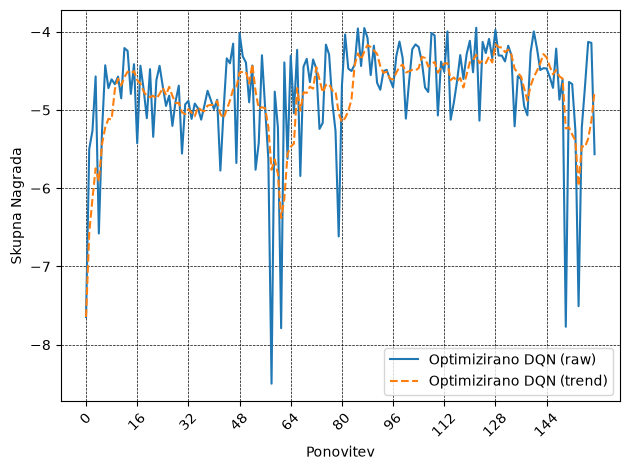

Zadnja raw nagrada: -5.56
Zadnja trend nagrada: -4.75


In [23]:
Y = [nagrada_seznam, nagrada_trend]
X = range(len(nagrada_seznam))
X_label = 'Ponovitev'
Y_label = 'Skupna Nagrada'
Legenda = ['Optimizirano DQN (raw)', 'Optimizirano DQN (trend)']
Naslov = 'Optimizacija preko 10 ponovitev DQN 2L 64 32N PC nagrada'
plotMultiY(X, Y, X_label, [Y_label], Legenda, Naslov, save_pdf=False)
print(f'Zadnja raw nagrada: {nagrada_seznam[-1]:.2f}')
print(f'Zadnja trend nagrada: {nagrada_trend[-1]:.2f}')

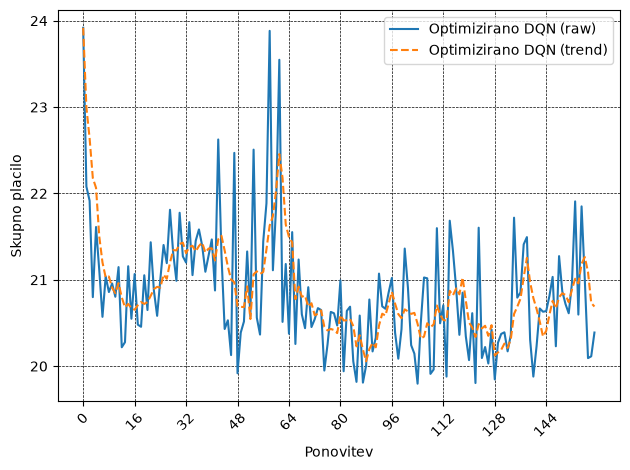

Zadnje raw placilo: 20.39
Zadnje trend placilo: 20.69


In [24]:
Y = [placilo_seznam, placilo_trend]
X = range(len(placilo_seznam))
X_label = 'Ponovitev'
Y_label = 'Skupno placilo'
Legenda = ['Optimizirano DQN (raw)', 'Optimizirano DQN (trend)']
Naslov = 'Optimizacija preko 10 ponovitev DQN 2L 64 32N PC placilo'
plotMultiY(X, Y, X_label, [Y_label], Legenda, Naslov, save_pdf=False)
print(f'Zadnje raw placilo: {placilo_seznam[-1]:.2f}')
print(f'Zadnje trend placilo: {placilo_trend[-1]:.2f}')

In [25]:
print(f'Nagrada po optimizaciji {nagradaDQN[-1]}')
print(f'Cena po optimizaciji {placiloDQN[-1]}')

Nagrada po optimizaciji -222.7951473649372
Cena po optimizaciji 1057.537498893363


### Grafi DQN

#### Grafi DQN setup

##### MILP
Bencmark using perfect predictions.

The teoretical optimum that can be reached by other algorithms


In [17]:
env = build_dqn_env(
    dataset=test_data,
    dataset_norm=test_data_norm,
    episode_length = len(test_data) - 1,#KorakovNaDan * 7,
    reset_mode="deterministic",
    observation_mode="sliding_window",
)
# The MILP benchmark itself now lives in Basic_Functions.run_milp_benchmark
# (single shared implementation used by all notebooks). It is imported in
# the import cell above; call it as:
#     df_milp = run_milp_benchmark(env, use_discrete_actions=True)
# Invoicing for the solved MILP trajectory is available there too:
#     df_milp = run_milp_benchmark(env, use_discrete_actions=True,
#                                  generate_invoice=True)


##### Brez baterije, brez panelov, policy baselines
The rest of setup


In [18]:
comparison_alternating_env = build_dqn_env(
    dataset=test_data,
    dataset_norm=test_data_norm,
    episode_length=len(test_data) - 1,
    reset_mode="deterministic",
    observation_mode="sliding_window",
)

comparison_dates = build_plot_timeline(test_data, placiloDQN)

In [19]:
alternating_trace = rollout_env_trace(comparison_alternating_env, policy_mode="alternating")

nakljucni_nagradaDQN, nakljucni_placiloDQN, nakljucni_baterijaDQN, nakljucni_NagradaKapaciteta, nakljucni_NagradaSprememba, nakljucni_NagradaPlacilo = Learning_DQN(
    ucenje=False,
    random=True,
    env=build_dqn_env(
        dataset=test_data,
        dataset_norm=test_data_norm,
        episode_length=len(test_data) - 1,
        reset_mode="deterministic",
        observation_mode="sliding_window",
    ),
)

print(f'Cena DQN z epsilon=1 {nakljucni_placiloDQN[-1]}')
print(f'Cena izmeničnih akcij {alternating_trace.Price[-1]}')

Random eval: epsilon = 1.0
Episode: 1
Steps per episode: 17535
Epsilon 1.0000
Final price: 1132.72 EUR
Cena DQN z epsilon=1 1132.7194386868414
Cena izmeničnih akcij 1068.6882299472081


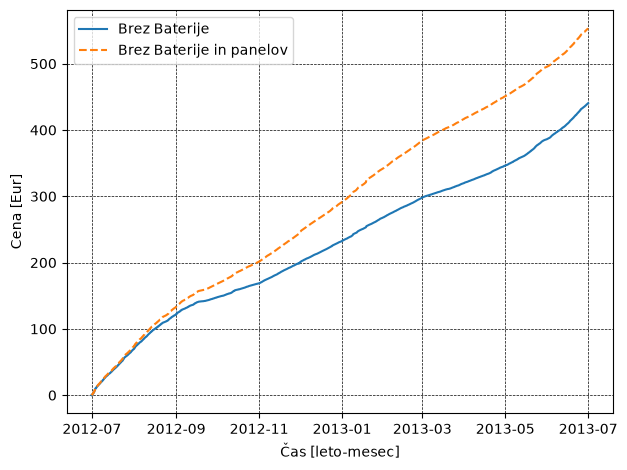

Placilo brez panelov 553.3717232068798
Placilo brez baterije 440.45894933819585


In [20]:
cena = test_data["SMP"]
proizvodnja = test_data["Energy_Generation"]
poraba = test_data["Energy_Consumption"]
zero_generation = pd.Series(0.0, index=test_data.index)
Placilo_brez_baterije_skupno = cumulative_interval_price_series(poraba, proizvodnja, env, test_data)
Placilo_brez_panelov_skupno = cumulative_interval_price_series(poraba, zero_generation, env, test_data)

Y = [Placilo_brez_baterije_skupno, Placilo_brez_panelov_skupno]
X = comparison_dates
X_label = 'Čas [leto-mesec]'
Y_label = 'Cena [Eur]'
Legenda = ['Brez Baterije', 'Brez Baterije in panelov']
Naslov = 'Vpliv panelov na ceno elektrike pri odkupu po polovični ceni'
plotMultiY(X, Y, X_label, [Y_label],Legenda ,Naslov, save_pdf=False)

print(f"Placilo brez panelov {Placilo_brez_panelov_skupno[-1]}")
print(f"Placilo brez baterije {Placilo_brez_baterije_skupno[-1]}")

In [21]:
no_battery_env = HouseholdEnvironment(
    dataset=test_data,
    dataset_norm=test_data_norm,
    observation_mode="sliding_window",
    reset_mode="deterministic",
    episode_length=len(test_data) - 1,
    korakov_na_dan=KorakovNaDan,
    bat_kapaciteta=0,
    bat_ucinkovitost=BatUcinkovitost,
    bat_max_polnjenje=BatMaxPolnjenje,
    bat_max_praznjenje=BatMaxPraznjenje,
    faktor_n1=faktorN1,
    faktor_n2=faktorN2,
    faktor_n3=faktorN3,
    generate_monthly_invoice=GENERATE_BASELINE_INVOICE,
    generate_period_invoice=GENERATE_BASELINE_INVOICE,
    invoice_run_label="baseline_no_battery",
)

agent_brez_baterije = rollout_env_trace(no_battery_env, policy_mode="fixed")

#### Grafi DQN analiza poskusa

In [22]:
save_pdf = False
save_png = False
print(f'BatUcinkovitost: {BatUcinkovitost}')
print(f'BatKapaciteta: {BatKapaciteta}')
print(f'faktorN1: {faktorN1}')
print(f'faktorN2: {faktorN2}')
print(f'faktorN3: {faktorN3}')
print(f'Nagrada po optimizaciji {nagradaDQN[-1]}')
print(f'Cena po optimizaciji DQN {placiloDQN[-1]}')
print(f'gamma: {gamma} ')
print(f'lr: {lr} ')
print(f'epsilon_start: {epsilon_start} ')
print(f'epsilon_end: {epsilon_end} ')
print(f'epsilon_decay: {epsilon_decay} ')
print(f'batch_size: {batch_size} ')
print(f'fc1_dims: {fc1_dims} ')
print(f'fc2_dims: {fc2_dims} ')
print(f'fc3_dims: {fc3_dims} ')
print(f'replace_target: {replace_target} ')
print(f'weight_decay: {weight_decay} ')

# --- STEP 1: Run the MILP benchmark on your environment ---
# (run_milp_benchmark is the shared implementation in Basic_Functions.py)
df_milp = run_milp_benchmark(
    env, use_discrete_actions=True, generate_invoice=GENERATE_MILP_INVOICE,
)  # Set to True for discrete actions, False for continuous


BatUcinkovitost: 0.95
BatKapaciteta: 20
faktorN1: 0
faktorN2: 0
faktorN3: 1
Nagrada po optimizaciji -866.8767469078759
Cena po optimizaciji DQN 423.36872626940834
gamma: 0.99 
lr: 0.001 
epsilon_start: 1.0 
epsilon_end: 0.01 
epsilon_decay: 4e-05 
batch_size: 48 
fc1_dims: 256 
fc2_dims: 128 
fc3_dims: 64 
replace_target: 336 
weight_decay: 0.0001 
Building MILP Model...
Solving over 17535 steps... (This may take a moment)

--- MILP Optimization Complete ---
Total Electricity Cost (Inc GST & Fixed): 360.3993
Total RL Equivalent Reward: -136.5173


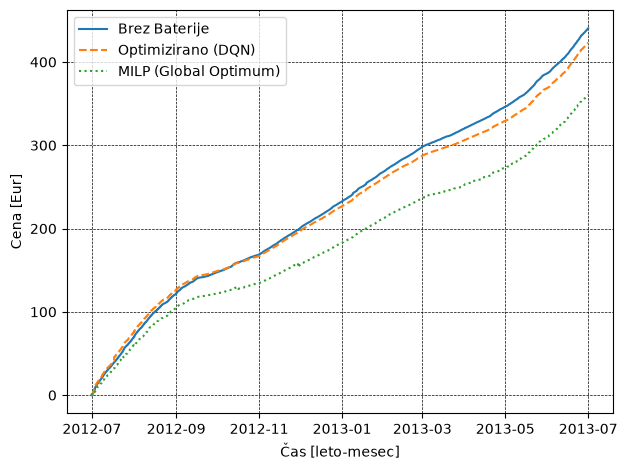

Placilo po optimizaciji (DQN): 423.36872626940834
Izboljšanje z DQN v primerjavi z DQN brez baterije: 3.88%
Placilo brez baterije: 440.43805712119587
Placilo z MILP (Teoretični Optimum): 360.3993370745229
Izboljšanje z MILP v primerjavi z DQN brez baterije: 18.17%
Zaostajanje DQN v primerjavi z MILP: 17.47%
Delež teoretične izboljšave ki jo je dosegel DQN: 21.33%


In [29]:

# --- STEP 2: Update the Plotting Variables ---
# Append the cumulative cost array from the MILP DataFrame to your list of Y values.
# We slice it using [:-1] to match the length of your other tracking variables.
Y = [
    #nakljucni_placiloDQN[:-1],
    agent_brez_baterije.Price[:-1], 
    placiloDQN[:-1], 
    df_milp["Cum_Cost"].to_numpy()[:-1].tolist()  # Added MILP Cumulative Cost as mutable list
]

X = comparison_dates
X_label = 'Čas [leto-mesec]'
Y_label = 'Cena [Eur]'

# Update the legend to include MILP so the colors match correctly
Legenda = ['Brez Baterije', 'Optimizirano (DQN)', 'MILP (Global Optimum)'] #'Naključno DQN', 

Naslov = 'Cena elektrike v drugi polovici podatkov DQN vs MILP'

# --- STEP 3: Plot the multi-line chart ---
plotMultiY(X, Y, X_label, [Y_label], Legenda, Naslov, save_pdf=save_pdf, save=save_png)

# --- STEP 4: Print the final financial comparison metrics ---
print(f'Placilo po optimizaciji (DQN): {placiloDQN[-1]}')
inprovement_percentage_DQN = ((agent_brez_baterije.Price[-1] - placiloDQN[-1]) / agent_brez_baterije.Price[-1]) * 100
print(f'Izboljšanje z DQN v primerjavi z DQN brez baterije: {inprovement_percentage_DQN:.2f}%')
print(f'Placilo brez baterije: {agent_brez_baterije.Price[-1]}')
print(f'Placilo z MILP (Teoretični Optimum): {df_milp["Cum_Cost"].iloc[-1]}')
inprovement_percentage_MILP = ((agent_brez_baterije.Price[-1] - df_milp["Cum_Cost"].iloc[-1]) / agent_brez_baterije.Price[-1]) * 100
print(f'Izboljšanje z MILP v primerjavi z DQN brez baterije: {inprovement_percentage_MILP:.2f}%')
print(f'Zaostajanje DQN v primerjavi z MILP: {(( placiloDQN[-1] -df_milp["Cum_Cost"].iloc[-1]) / df_milp["Cum_Cost"].iloc[-1]) * 100:.2f}%')
print(f'Delež teoretične izboljšave ki jo je dosegel DQN: {((agent_brez_baterije.Price[-1] - placiloDQN[-1]) / (agent_brez_baterije.Price[-1] - df_milp["Cum_Cost"].iloc[-1])) * 100:.2f}%')

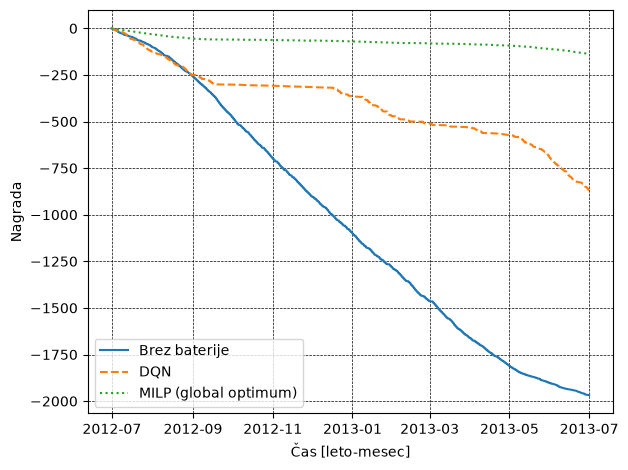

Nagrada po optimizaciji (DQN): -866.8767469078759
Izboljšanje z DQN v primerjavi z DQN brez baterije: 55.95%
Nagrada brez baterije: -1968.0450786902454
Placilo z MILP (Teoretični Optimum): 360.3993370745229
Izboljšanje z MILP v primerjavi z DQN brez baterije: 118.31%
Zaostajanje DQN v primerjavi z MILP: -340.53%
Delež teoretične izboljšave ki jo je dosegel DQN: 47.29%


In [30]:
### CELL 65: Primerjava skupne nagrade po različnih metodah

Y = [
    agent_brez_baterije.NagradaSkupno[:-1],
    nagradaDQN[:-1],
    df_milp["Cum_RL_Reward"].to_numpy()[:-1],
]
X = comparison_dates
X_label = 'Čas [leto-mesec]'
Y_label = 'Nagrada'
Legenda = ['Brez baterije', 'DQN', 'MILP (global optimum)']
Naslov = 'Primerjava nagrad baseline in DQN'
plotMultiY(X, Y, X_label, [Y_label],Legenda ,Naslov, save_pdf = save_pdf, save = save_png)
print(f'Nagrada po optimizaciji (DQN): {nagradaDQN[-1]}')
inprovement_percentage_DQN = ((agent_brez_baterije.NagradaSkupno[-1] - nagradaDQN[-1]) / agent_brez_baterije.NagradaSkupno[-1]) * 100
print(f'Izboljšanje z DQN v primerjavi z DQN brez baterije: {inprovement_percentage_DQN:.2f}%')
print(f'Nagrada brez baterije: {agent_brez_baterije.NagradaSkupno[-1]}')
print(f'Placilo z MILP (Teoretični Optimum): {df_milp["Cum_Cost"].iloc[-1]}')
inprovement_percentage_MILP = ((agent_brez_baterije.NagradaSkupno[-1] - df_milp["Cum_Cost"].iloc[-1]) / agent_brez_baterije.NagradaSkupno[-1]) * 100
print(f'Izboljšanje z MILP v primerjavi z DQN brez baterije: {inprovement_percentage_MILP:.2f}%')
print(f'Zaostajanje DQN v primerjavi z MILP: {(( nagradaDQN[-1] -df_milp["Cum_Cost"].iloc[-1]) / df_milp["Cum_Cost"].iloc[-1]) * 100:.2f}%')
print(f'Delež teoretične izboljšave ki jo je dosegel DQN: {((agent_brez_baterije.NagradaSkupno[-1] - nagradaDQN[-1]) / (agent_brez_baterije.NagradaSkupno[-1] - df_milp["Cum_Cost"].iloc[-1])) * 100:.2f}%')

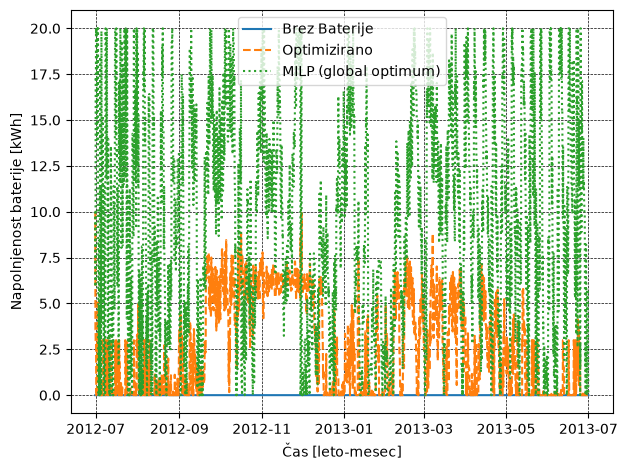

In [32]:
### CELL 62: Primerjava stanja baterije
Y = [
    #nakljucni_baterijaDQN[:-1],
    agent_brez_baterije.NapolnjenostBaterije[:-1],
    baterijaDQN[:-1],
    #alternating_trace.NapolnjenostBaterije[:-1],
    df_milp["SOC_kWh"].to_numpy()[:-1],
]
X = comparison_dates
X_label = 'Čas [leto-mesec]'
Y_label = 'Napolnjenost baterije [kWh]'
Legenda = ['Brez Baterije', 'Optimizirano', 'MILP (global optimum)']
Naslov = 'Napolnjenost baterije sistem Q spodbujevalnega učenja DQN'
plotMultiY(X, Y, X_label, [Y_label],Legenda ,Naslov, save_pdf = save_pdf, save = save_png)
